In [ ]:
# ── 1. Установка и Google Drive ──
!pip install -q ultralytics kagglehub

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.6 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# ── 2. Датасет ──
import os, glob, yaml
import kagglehub
path = kagglehub.dataset_download("saumyapatel/traffic-vehicles-object-detection")
DATA = os.path.dirname(glob.glob(f"{path}/**/images", recursive=True)[0])  # корень с images/ и labels/
print("Данные:", DATA)

100%|██████████| 607M/607M [00:06<00:00, 96.8MB/s]

Extracting files...


Данные: /root/.cache/kagglehub/datasets/saumyapatel/traffic-vehicles-object-detection/versions/1/Traffic Dataset


In [ ]:
# ── 3. data.yaml (структура и классы известны заранее) ──
yaml_path = "/content/data.yaml"
yaml.safe_dump({
    "path": DATA, "train": "images/train", "val": "images/val", "test": "images/test",
    "nc": 7,
    "names": ['Car', 'Number Plate', 'Blur Number Plate', 'Two Wheeler', 'Auto', 'Bus', 'Truck'],
}, open(yaml_path, "w"), allow_unicode=True)
print(open(yaml_path).read())

names:
- Car
- Number Plate
- Blur Number Plate
- Two Wheeler
- Auto
- Bus
- Truck
nc: 7
path: /root/.cache/kagglehub/datasets/saumyapatel/traffic-vehicles-object-detection/versions/1/Traffic
  Dataset
test: images/test
train: images/train
val: images/val



In [ ]:
# ── 4. Обучение ──
from ultralytics import YOLO
DRIVE = "/content/drive/MyDrive/yolo_traffic"
model = YOLO("yolov8n.pt")
results = model.train(data=yaml_path, epochs=100, patience=20,
                      imgsz=640, batch=16, project=DRIVE, name="train", exist_ok=True)
print("Сохранено в:", results.save_dir)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

results.png


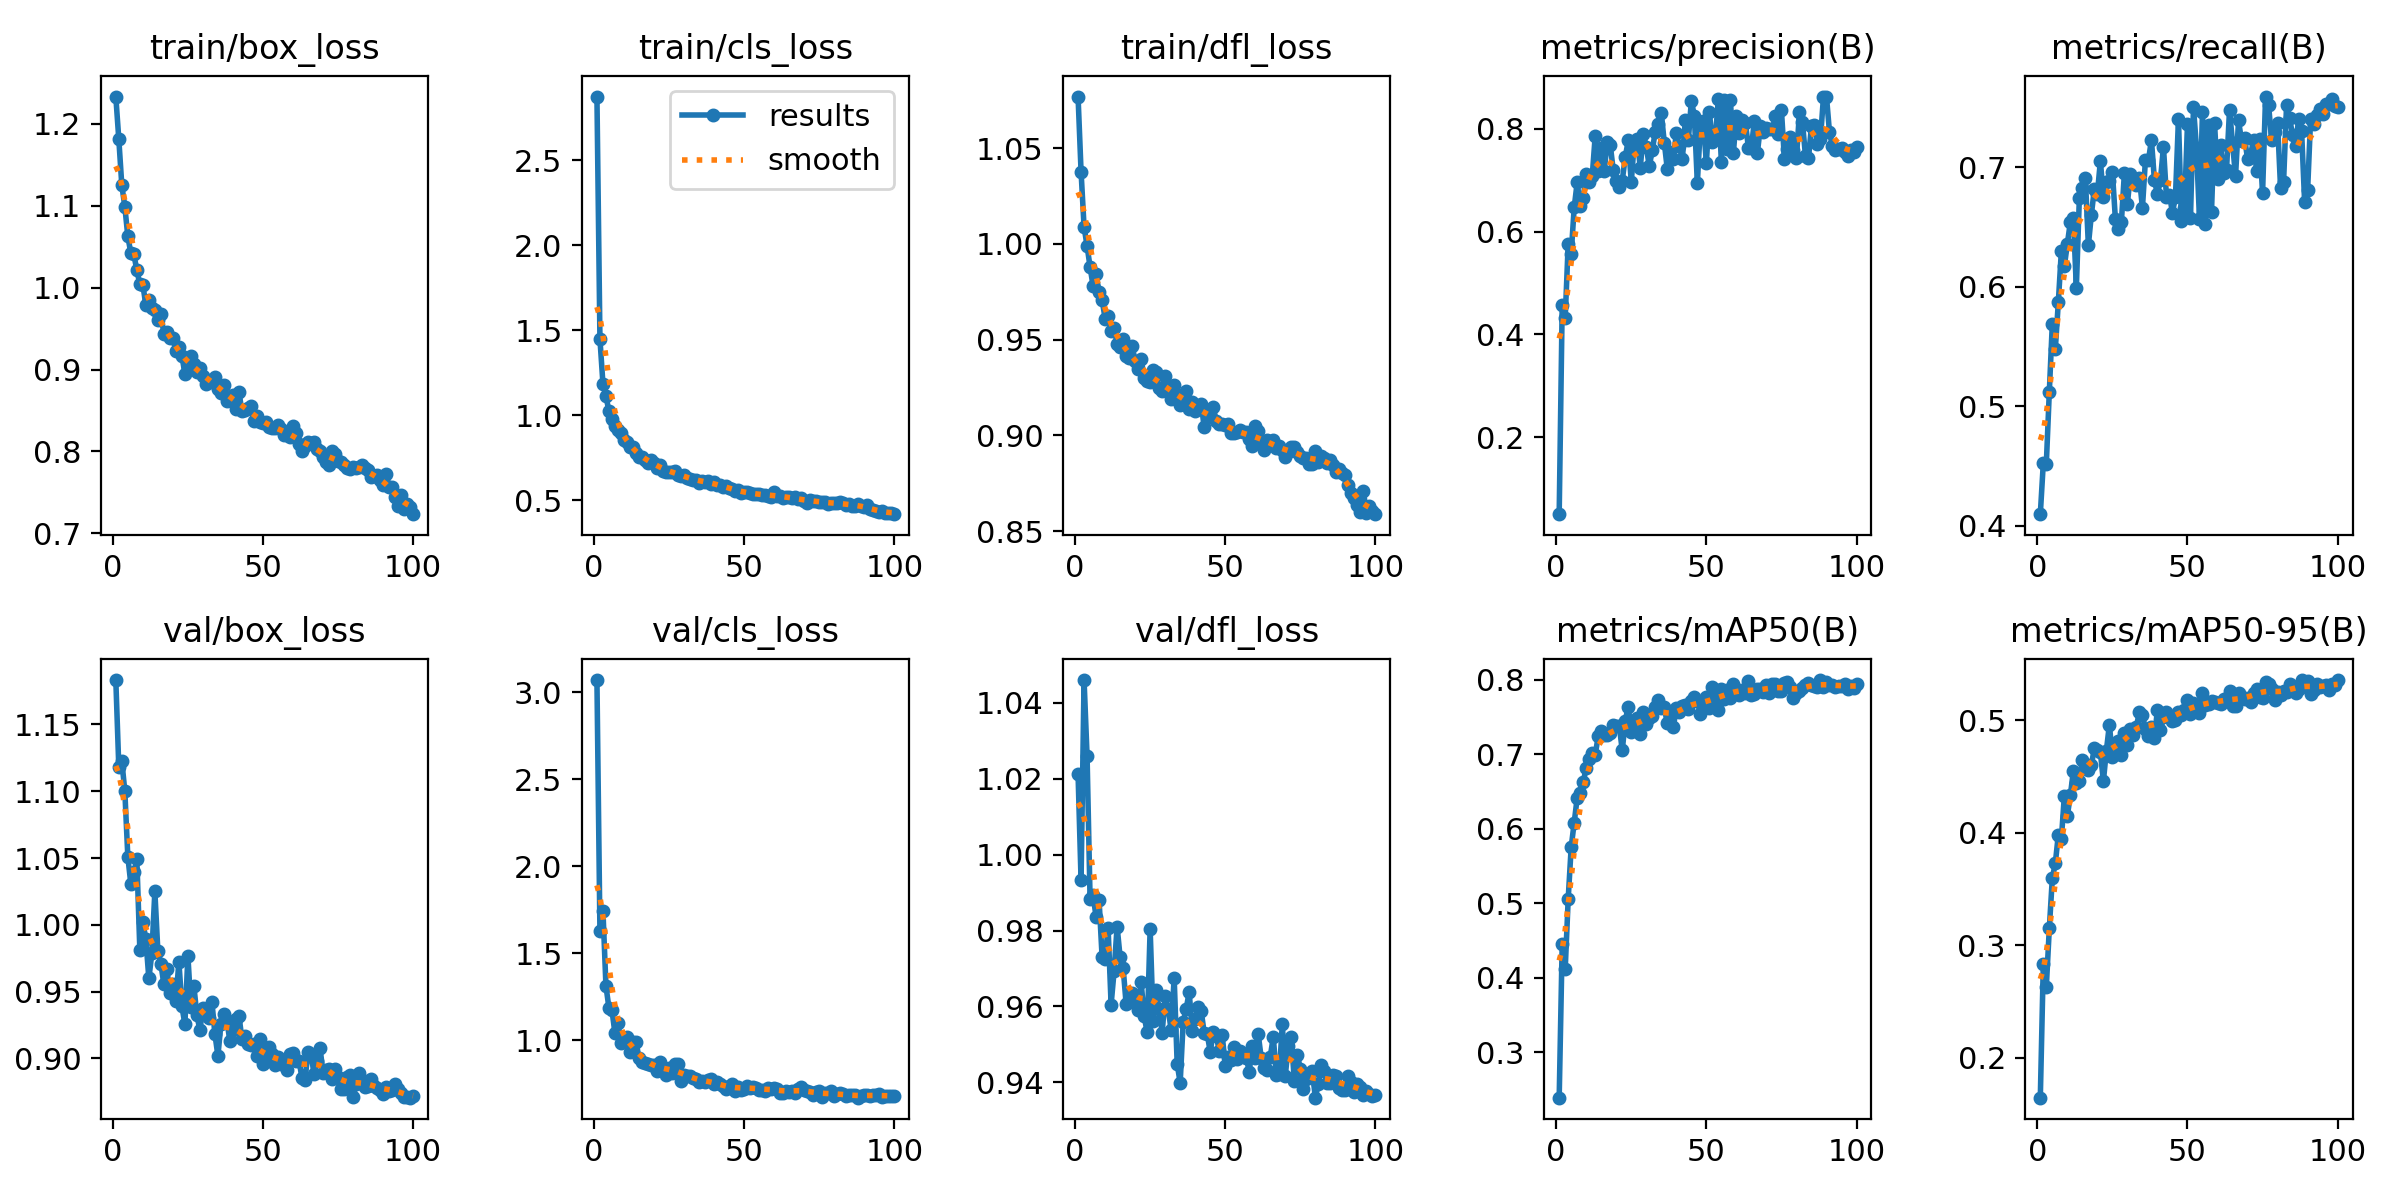

confusion_matrix.png


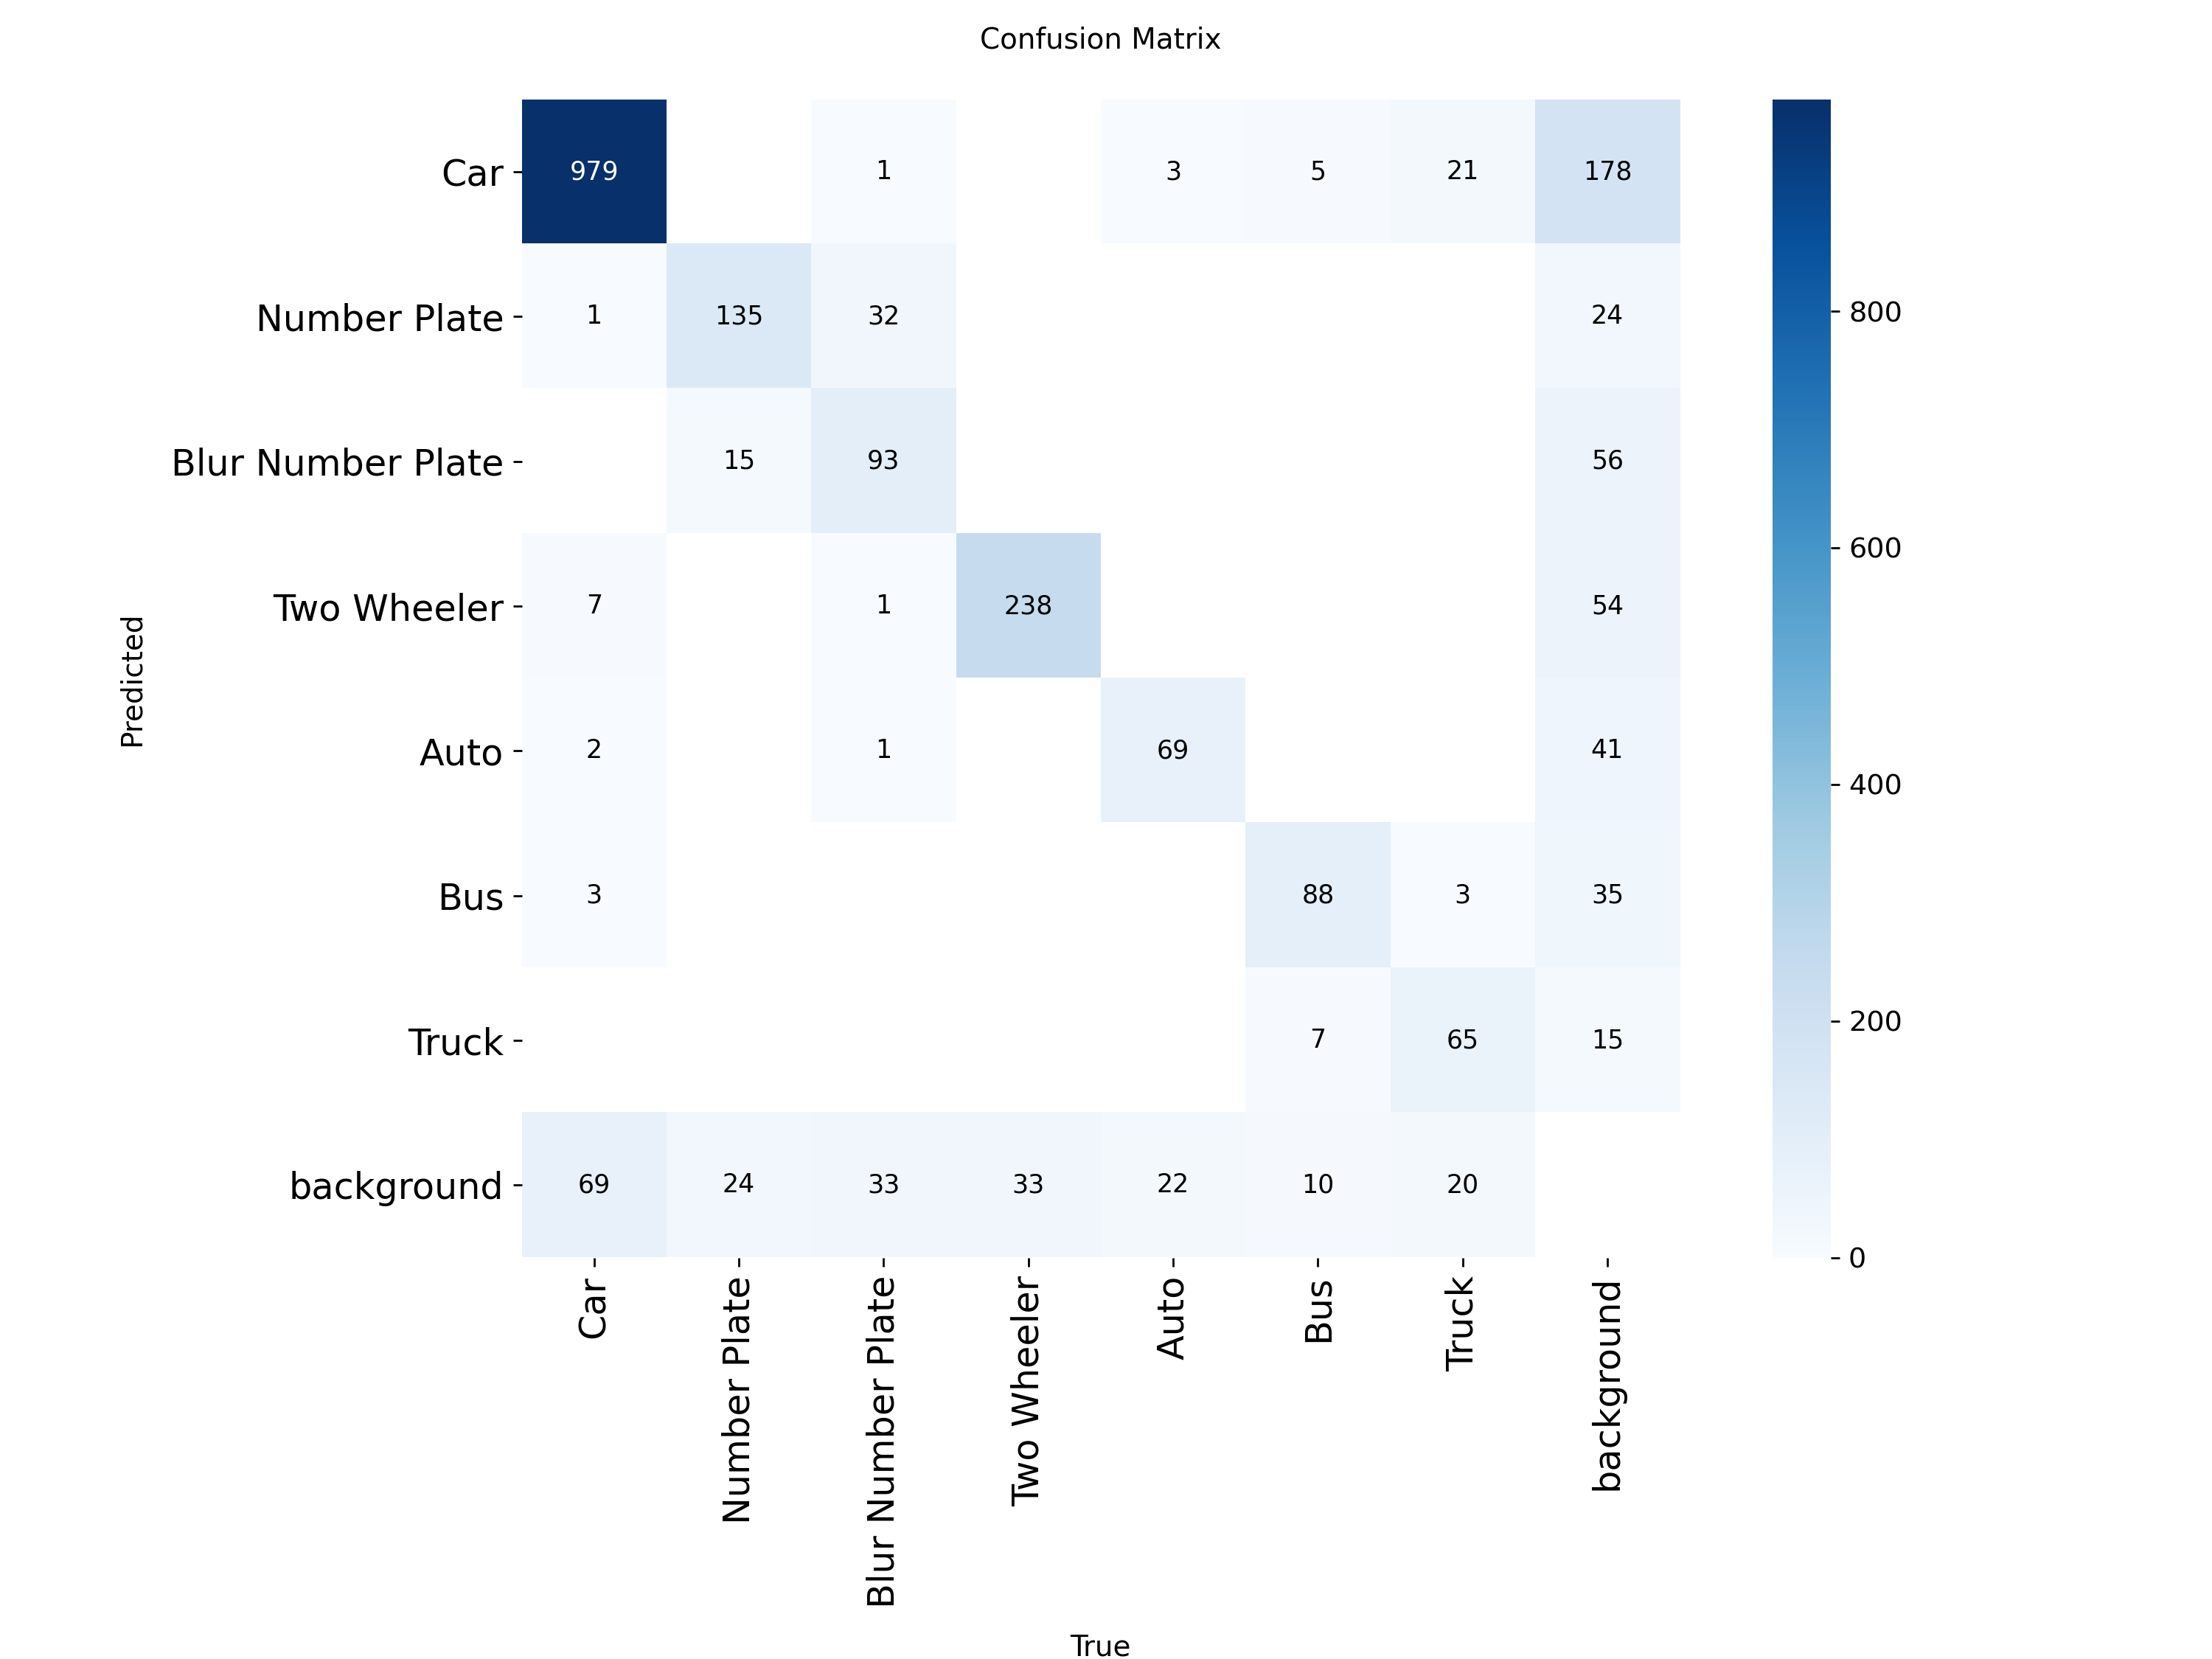

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2881.3±673.8 MB/s, size: 104.6 KB)
val: Scanning /root/.cache/kagglehub/datasets/saumyapatel/traffic-vehicles-object-detection/versions/1/Traffic Dataset/labels/val.cache... 185 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 185/185 59.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.9it/s 6.3s
                   all        185       1980      0.804      0.723      0.798      0.538
                   Car        159       1061      0.897      0.913      0.944      0.764
          Number Plate        104        174      0.831      0.764      0.818      0.506
     Blur Number Plate         80        161      0.756        0.5      0.642      0.319
           Two Wheeler         88        271       

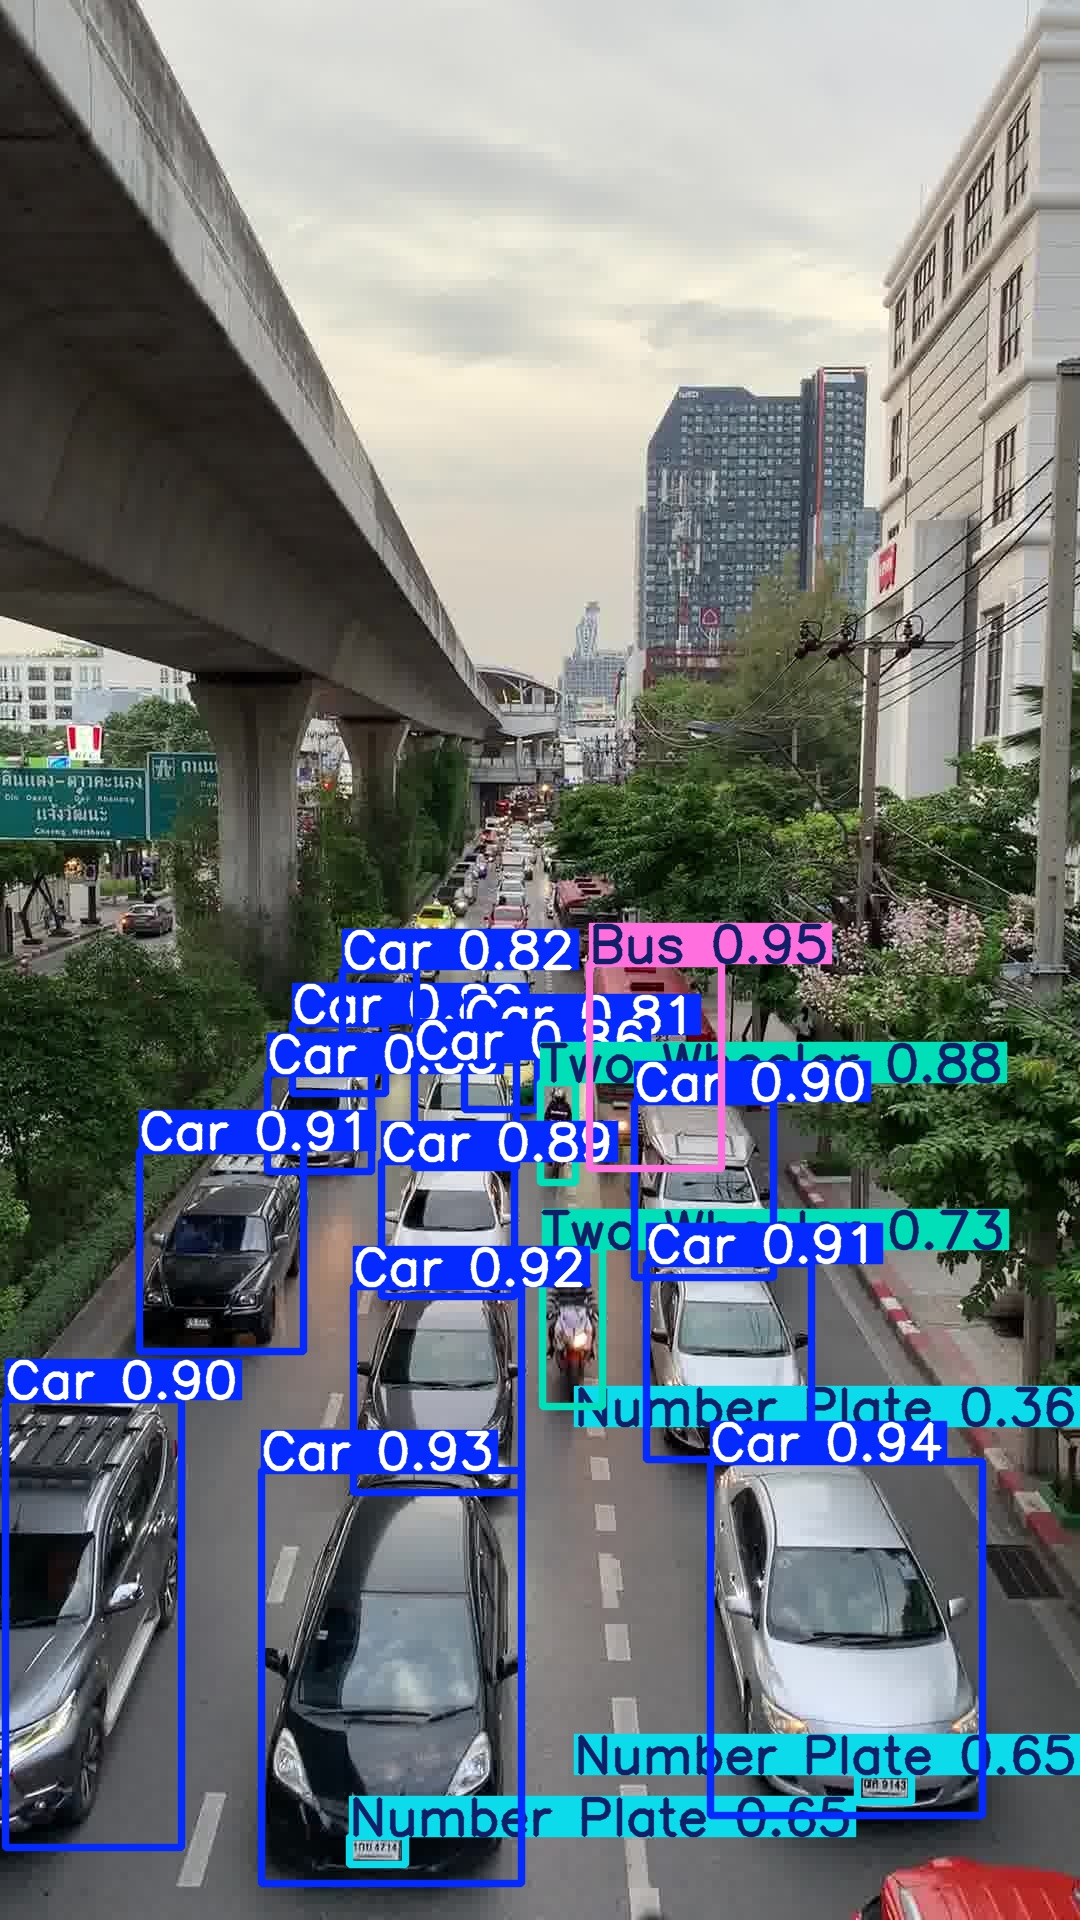

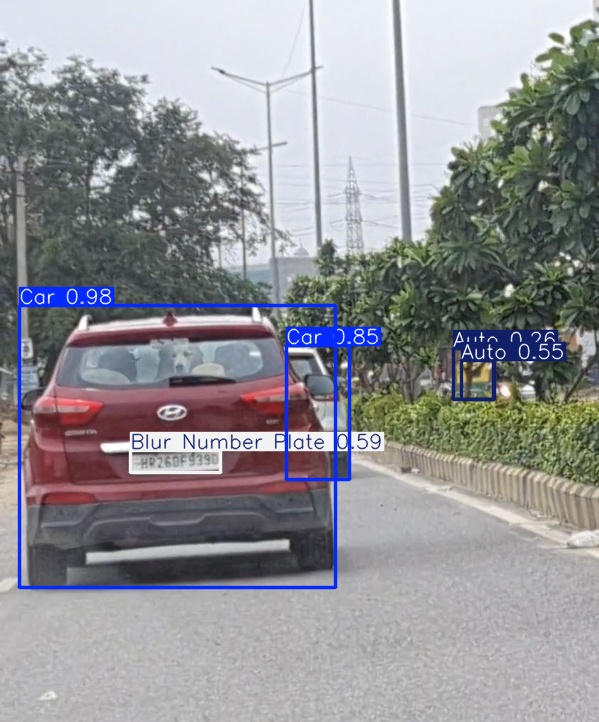

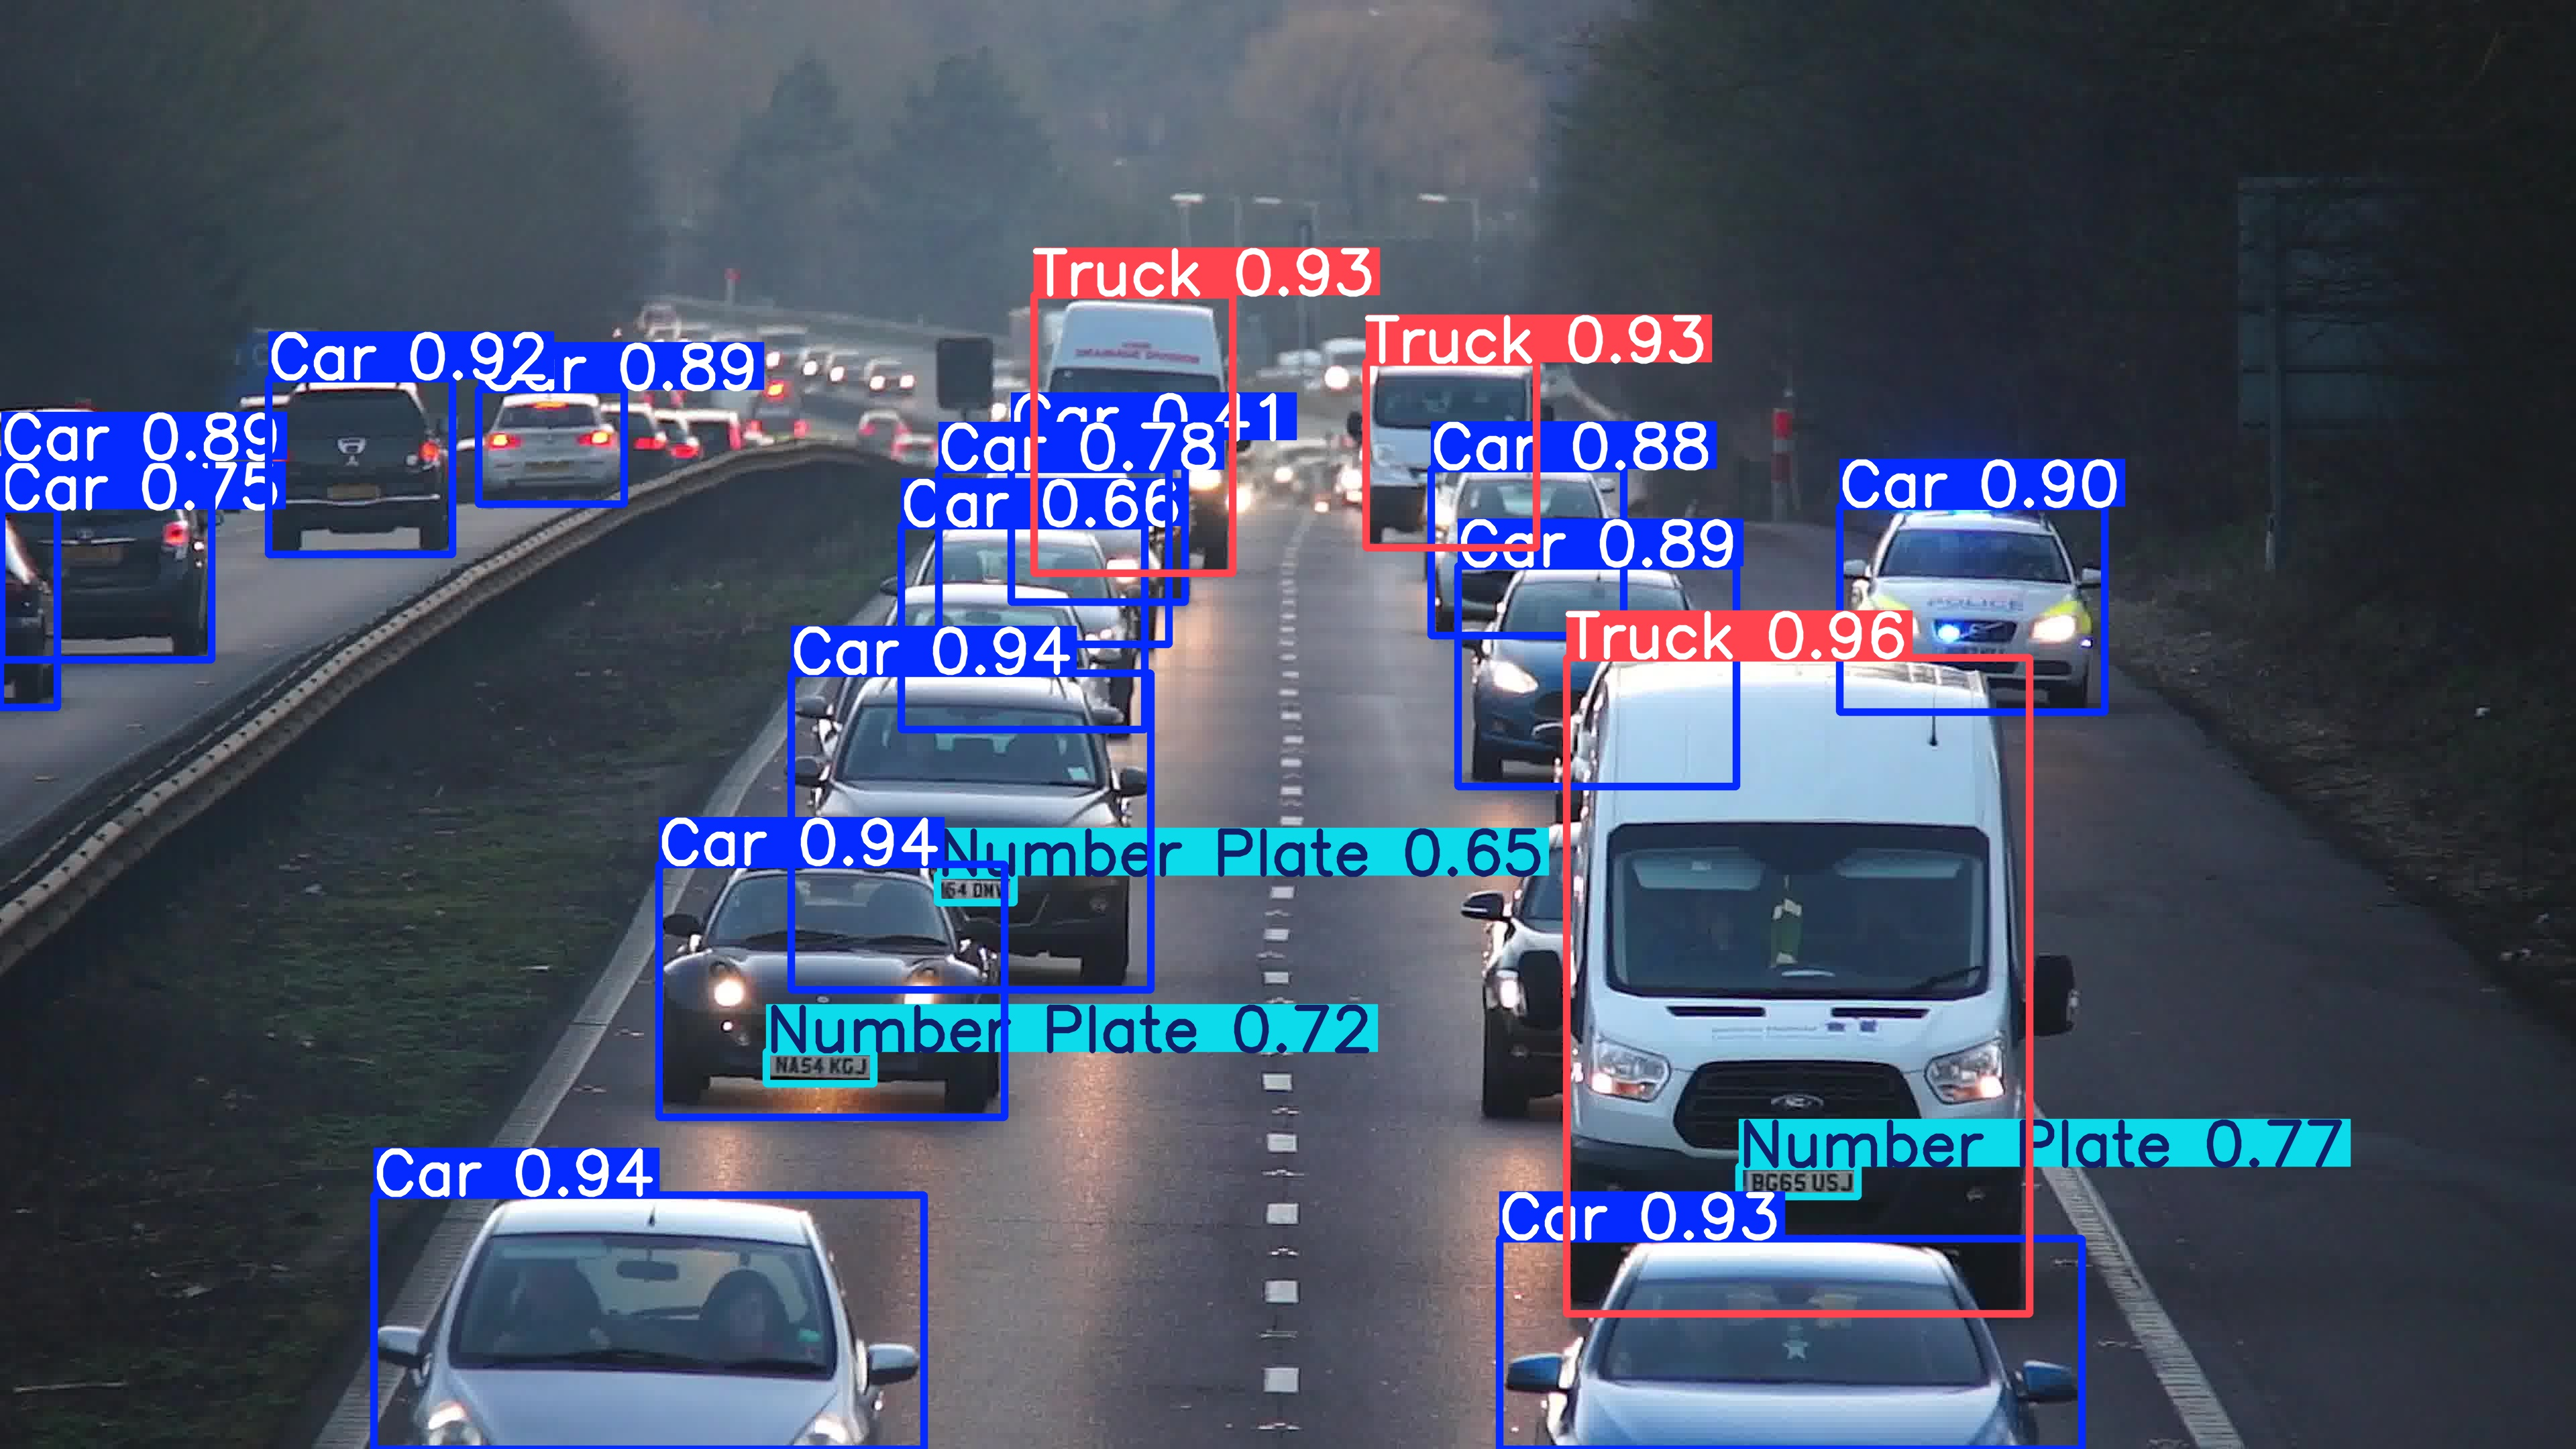

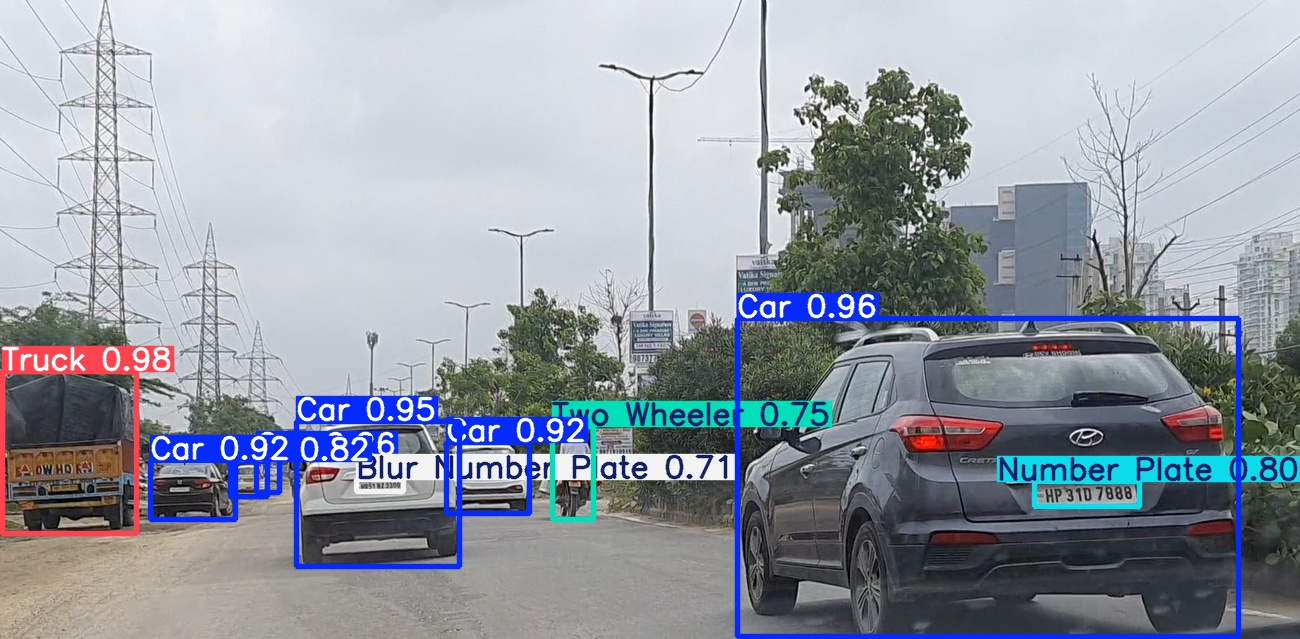

In [ ]:
# ── 5. Метрики и примеры детекций ──
from IPython.display import Image, display
rd = str(results.save_dir)
for f in ["results.png", "confusion_matrix.png", "PR_curve.png"]:
    p = os.path.join(rd, f)
    if os.path.exists(p):
        print(f); display(Image(filename=p, width=750))

best = os.path.join(rd, "weights", "best.pt")
m = YOLO(best).val(data=yaml_path)
print(f"mAP50 = {m.box.map50:.3f}, mAP50-95 = {m.box.map:.3f}")

# ── Примеры детекций: берём ТОЛЬКО изображения, видео пропускаем ──
test_imgs = [f for f in glob.glob(f"{DATA}/images/test/*")
             if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))][:4]
if test_imgs:
    res = YOLO(best).predict(test_imgs, conf=0.25, save=True)
    for f in glob.glob(f"{res[0].save_dir}/*.jpg"):
        display(Image(filename=f, width=750))